In [1]:
%load_ext autoreload
%autoreload 2
import tqdm, tqdm.notebook

tqdm.tqdm = tqdm.notebook.tqdm  # notebook-friendly progress bars
from pathlib import Path
import numpy as np

from hloc import (
    extract_features,
    match_features,
    reconstruction,
    visualization,
    pairs_from_exhaustive,
)
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d

In [2]:
images = Path("datasets/A")
outputs = Path("outputs/demo/")
!rm -rf $outputs
sfm_pairs = outputs / "pairs-sfm.txt"
loc_pairs = outputs / "pairs-loc.txt"
sfm_dir = outputs / "sfm"
features = outputs / "features.h5"
matches = outputs / "matches.h5"

feature_conf = extract_features.confs["superpoint_inloc"]
matcher_conf = match_features.confs["superpoint+lightglue"]

'rm' ���O�����Υ~���R�O�B�i���檺�{���Χ妸�ɡC


3 mapping images


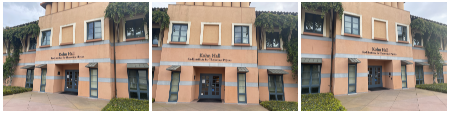

In [3]:
references = [p.relative_to(images).as_posix() for p in (images).iterdir()]
print(len(references), "mapping images")
plot_images([read_image(images / r) for r in references], dpi=25)

In [4]:
extract_features.main(
    feature_conf, images, image_list=references, feature_path=features
)
pairs_from_exhaustive.main(sfm_pairs, image_list=references)
match_features.main(matcher_conf, sfm_pairs, features=features, matches=matches);

[2025/04/25 12:12:02 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 4},
 'output': 'feats-superpoint-n4096-r1600',
 'preprocessing': {'grayscale': True, 'resize_max': 1600}}
[2025/04/25 12:12:02 hloc INFO] Skipping the extraction.
[2025/04/25 12:12:02 hloc INFO] Found 3 pairs.
[2025/04/25 12:12:02 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
[2025/04/25 12:12:02 hloc INFO] Skipping the matching.


In [5]:
import h5py
import numpy as np
import cv2

img1_name = 'IMG_1223.JPG'
img2_name = 'IMG_1224.JPG'
img3_name = 'IMG_1226.JPG'

# Load keypoints from features.h5
with h5py.File('outputs/demo/features.h5', 'r') as f:
    kpts1 = f[img1_name]['keypoints'][:]
    kpts2 = f[img2_name]['keypoints'][:]
    kpts3 = f[img3_name]['keypoints'][:]

# Load LightGlue matches0 from matches.h5
with h5py.File('outputs/demo/matches.h5', 'r') as f:
    matches0 = f[img1_name][img2_name]['matches0'][:]  # shape (N1,)
    matches1 = f[img2_name][img3_name]['matches0'][:]  # shape (N1,)
    matches2 = f[img1_name][img3_name]['matches0'][:]  # shape (N1,)

# Valid matches are those >= 0
valid_ab = matches0 > -1
pts_A = kpts1[valid_ab]
pts_B = kpts2[matches0[valid_ab]]

# B-C matching
valid_bc = matches1 > -1
pts_B2 = kpts2[valid_bc]
pts_C = kpts3[matches1[valid_bc]]

# A-C direct matching
valid_ac = matches2 > -1
pts_A2 = kpts1[valid_ac]
pts_C2 = kpts3[matches2[valid_ac]]
pts_A = np.array(pts_A, dtype=np.float32)
pts_B = np.array(pts_B, dtype=np.float32)
pts_C = np.array(pts_C, dtype=np.float32)
pts_A2 = np.array(pts_A2, dtype=np.float32)
pts_B2 = np.array(pts_B2, dtype=np.float32)
pts_C2 = np.array(pts_C2, dtype=np.float32)

from Homography import Homography

# Compute homographies
HMG = Homography()
H1 = HMG.compute_homography_dlt_normalized(pts_A[:10], pts_B[:10])   # A to B
H2 = HMG.compute_homography_dlt_normalized(pts_B2[:10], pts_C[:10])  # B to C
H3 = HMG.compute_homography_dlt_normalized(pts_A2[:10], pts_C2[:10]) # A to C
HA = np.matmul(H1,np.append(pts_A[10],1))
HB = np.matmul(H2,np.append(pts_B2[10],1))
HC = np.matmul(H3,np.append(pts_A2[10],1))
CA = [HA[0]/HA[2],HA[1]/HA[2]]
CB = [HB[0]/HB[2],HB[1]/HB[2]]
CC = [HC[0]/HC[2],HC[1]/HC[2]]
print("Validation A-B: Point in A:",pts_A[10],"Point in B:",pts_B[10],"Reconstructed Point:",CA)
print("Validation B-C: Point in B:",pts_B2[10],"Point in C:",pts_C[10],"Reconstructed Point:",CB)
print("Validation A-C: Point in A:",pts_A2[10],"Point in C:",pts_C2[10],"Reconstructed Point:",CC)

Validation A-B: Point in A: [1609. 1543.] Point in B: [1399. 1586.] Reconstructed Point: [1381.220392098849, 1544.9630584356992]
Validation B-C: Point in B: [590.5 646. ] Point in C: [1198.    386.25] Reconstructed Point: [1282.7484025826654, 387.4460662747463]
Validation A-C: Point in A: [2994.    494.75] Point in C: [3098.  744.] Reconstructed Point: [3031.2672142518263, 736.6908578505097]


Estimated Fundamental Matrix F1:
 [[-6.08865386e-09  2.43165119e-07 -5.06218438e-04]
 [-1.11374095e-09  7.94724970e-09  1.59049058e-03]
 [ 5.80031641e-05 -2.23352737e-03  1.00000000e+00]]
Estimated Fundamental Matrix F2:
 [[-3.04291895e-09  1.67311919e-07 -3.18427096e-04]
 [ 6.31999465e-08  4.67178113e-08  1.34795563e-03]
 [-7.75015565e-05 -1.83163634e-03  1.00000000e+00]]
Estimated Fundamental Matrix F3:
 [[-5.84739252e-09  1.05866529e-07 -2.07244260e-04]
 [ 1.39813490e-07  1.03342696e-08  4.67462798e-04]
 [-2.18772507e-04 -9.96768575e-04  1.00000000e+00]]


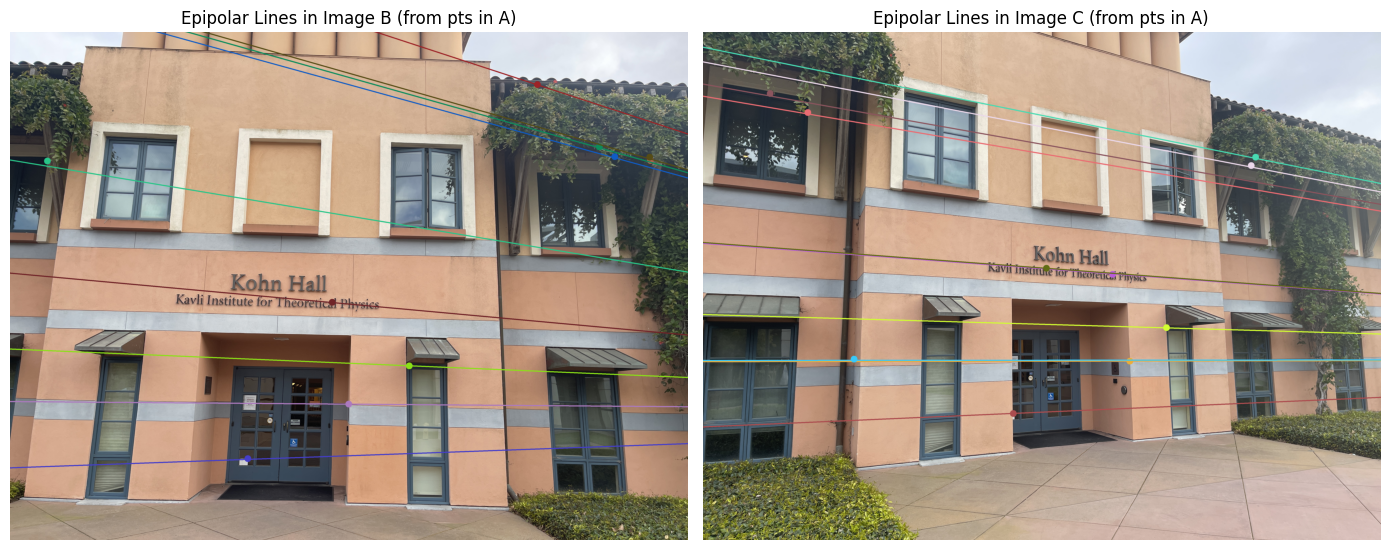

In [6]:
from FundamentalMat import FundamentalMat

FM = FundamentalMat()
F1 = FM.compute_fundamental_matrix_normalized(pts_A[:10], pts_B[:10])
F2 = FM.compute_fundamental_matrix_normalized(pts_B2[:10], pts_C[:10])
F3 = FM.compute_fundamental_matrix_normalized(pts_A2[:10], pts_C2[:10])
print("Estimated Fundamental Matrix F1:\n", F1)
print("Estimated Fundamental Matrix F2:\n", F2)
print("Estimated Fundamental Matrix F3:\n", F3)
img_A = cv2.imread('G:\Machine Learning\Hierarchical-Localization\datasets\A\IMG_1223.jpg')
img_B = cv2.imread('G:\Machine Learning\Hierarchical-Localization\datasets\A\IMG_1224.jpg')
img_C = cv2.imread('G:\Machine Learning\Hierarchical-Localization\datasets\A\IMG_1226.jpg')
FM.draw_epipolar_lines(img_A, img_B, img_C, pts_A[:10], pts_B[:10], pts_A2[:10], pts_C2[:10], F1, F3)